### Mini Project: COVID-19 Detection from Chest X-rays using CNN
This project builds a Convolutional Neural Network (CNN) model to automatically detect COVID-19 from chest X-ray images. The dataset contains three classes: COVID-19, Normal (no disease), and Viral Pneumonia.

In [2]:
# Imports necessary libraries for data processing, visualization, deep learning (TensorFlow/Keras), and hyperparameter tuning.
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
import kagglehub

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Loading and Exploration

Loaded 251 training images and 66 test images.


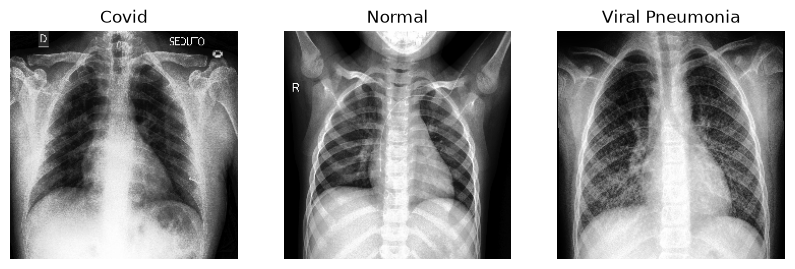

In [3]:
# Loads images from train and test folders, resizes them to 224x224, labels them, and prints dataset sizes.
base_dir = kagglehub.dataset_download('pranavraikokte/covid19-image-dataset') + '/Covid19-dataset'
classes = ['Covid', 'Normal', 'Viral Pneumonia']
img_size = 224

def load_data(folder_name):
    X_data, y_data = [], []
    for category in classes:
        path = os.path.join(base_dir, folder_name, category)
        class_num = classes.index(category)
        for img in os.listdir(path):
            img_array = cv2.imread(os.path.join(path, img))
            if img_array is not None:
                resized_array = cv2.resize(img_array, (img_size, img_size))
                X_data.append(resized_array)
                y_data.append(class_num)
    return np.array(X_data), y_data

X_train_full, y_train_full_list = load_data('train')
X_test, y_test_list = load_data('test')

print(f"Loaded {len(X_train_full)} training images and {len(X_test)} test images.")

# Display a few sample images from each class
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = y_train_full_list.index(i)
    plt.imshow(cv2.cvtColor(X_train_full[idx], cv2.COLOR_BGR2RGB))
    plt.title(classes[i])
    plt.axis('off')
plt.show()

# Convert label lists to numpy arrays for further processing
y_train_full = np.array(y_train_full_list)
y_test = np.array(y_test_list)

### EDA Class Distribution

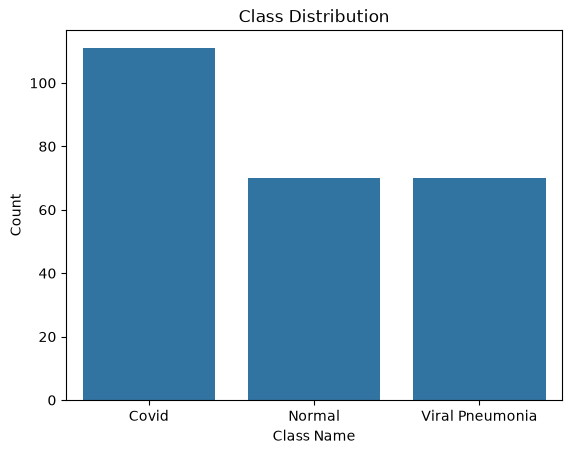

In [4]:
# Visualizes the class distribution using a bar plot to observe patterns in the data.
sns.countplot(x=[classes[label] for label in y_train_full])
plt.title('Class Distribution')
plt.xlabel('Class Name')
plt.ylabel('Count')
plt.show()

### Preprocess and split only validation from train

In [5]:
# Normalizes pixel values, encodes labels, and splits the training data to create a validation set (80-20% split).
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

y_train_full_encoded = to_categorical(y_train_full, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full_encoded, test_size=0.2, random_state=42)

### Handle Class Imbalance

In [6]:
# Analyzes class imbalance and sets up techniques like computing class weights and data augmentation using ImageDataGenerator.
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(class_weights))

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)

### Model Evaluation Function

In [7]:
# Defines a reusable function to evaluate models, plot train vs val metrics, print ROC-AUC/Test Acc, and display the confusion matrix.
def evaluate_model(model, history, X_test, y_test):

    print(f"Trainable Parameters: {np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])}")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {accuracy:.4f}\n")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Overfitting Check: Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Overfitting Check: Accuracy')
    plt.show()
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
    print(f"ROC-AUC Score (OVR): {roc_auc:.4f}\n")
    
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))
    
    # Confusion Matrix Heatmap
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Model 1: Basic CNN with Dropout and Augmentation

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 789ms/step - accuracy: 0.3650 - loss: 31.4091 - val_accuracy: 0.4706 - val_loss: 5.2140
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 640ms/step - accuracy: 0.4350 - loss: 7.3996 - val_accuracy: 0.6863 - val_loss: 2.3002
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 735ms/step - accuracy: 0.4900 - loss: 2.5939 - val_accuracy: 0.7843 - val_loss: 0.5811
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 707ms/step - accuracy: 0.6450 - loss: 0.8982 - val_accuracy: 0.8235 - val_loss: 0.5932
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 791ms/step - accuracy: 0.6350 - loss: 0.8342 - val_accuracy: 0.7451 - val_loss: 0.6854
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 782ms/step - accuracy: 0.5450 - loss: 0.8586 - val_accuracy: 0.7647 - val_loss: 0.6255
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 725ms/step - accuracy: 0.5900 - loss: 0.8780 - val_accuracy: 0.8627 - val_loss: 0.5685
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 675ms/step - accuracy: 0.6200 - loss: 0.8150 - val_accuracy: 0.8235 - val_loss

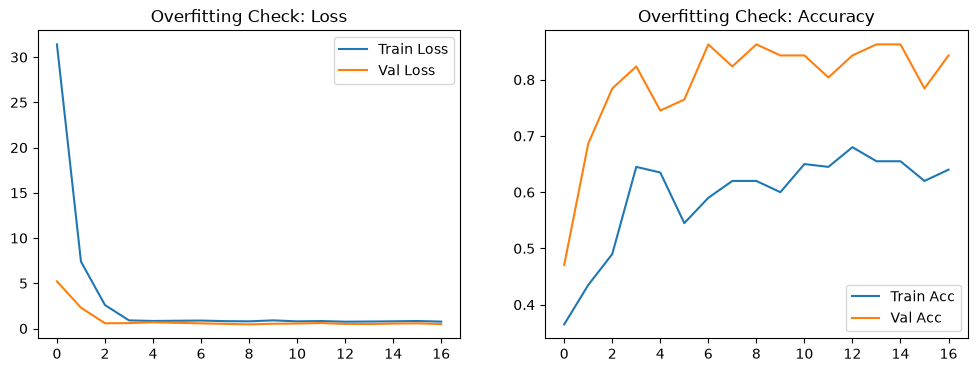

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
ROC-AUC Score (OVR): 0.9043

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      0.77      0.87        26
         Normal       0.60      0.75      0.67        20
Viral Pneumonia       0.67      0.70      0.68        20

       accuracy                           0.74        66
      macro avg       0.76      0.74      0.74        66
   weighted avg       0.78      0.74      0.75        66



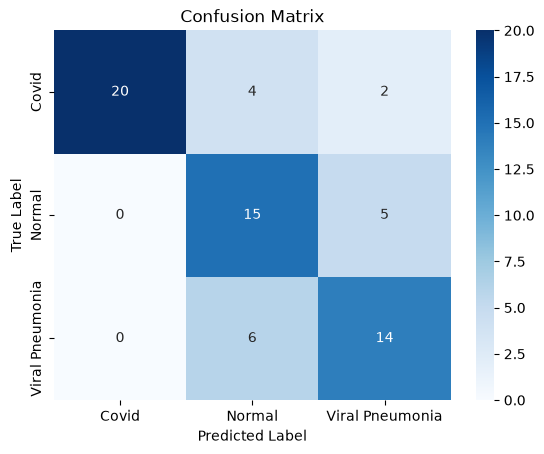

In [8]:
# Creates and trains a basic CNN with Dropout and Data Augmentation to prevent overfitting.
model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3), 
    Dense(3, activation='softmax')
])

model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history_1 = model_1.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)
evaluate_model(model_1, history_1, X_test, y_test)

### Model 2: Basic CNN with Dropout and Augmentation

c:\Users\singh\OneDrive\Desktop\cnn_mini_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 802ms/step - accuracy: 0.3900 - loss: 2.0589 - val_accuracy: 0.3529 - val_loss: 1.1719
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 715ms/step - accuracy: 0.4550 - loss: 1.0651 - val_accuracy: 0.2941 - val_loss: 1.0121
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 725ms/step - accuracy: 0.5000 - loss: 0.9776 - val_accuracy: 0.5294 - val_loss: 0.8918
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 720ms/step - accuracy: 0.6300 - loss: 0.8597 - val_accuracy: 0.7843 - val_loss: 0.6110
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 713ms/step - accuracy: 0.6750 - loss: 0.7748 - val_accuracy: 0.8627 - val_loss: 0.4741
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 698ms/step - accuracy: 0.7500 - loss: 0.5975 - val_accuracy: 0.6863 - val_loss: 1.0521
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 836ms/step - accuracy: 0.6950 - loss: 0.8464 - val_accuracy: 0.7647 - val_loss: 0.7489
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 736ms/step - accuracy: 0.5950 - loss: 0.8004 - val_accuracy: 0.8039 - val_loss:

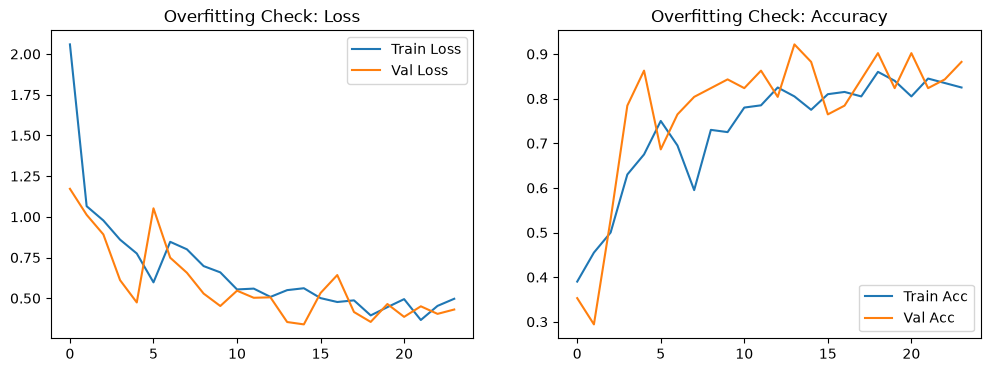

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
ROC-AUC Score (OVR): 0.9400

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      0.92      0.96        26
         Normal       0.69      0.90      0.78        20
Viral Pneumonia       0.75      0.60      0.67        20

       accuracy                           0.82        66
      macro avg       0.81      0.81      0.80        66
   weighted avg       0.83      0.82      0.82        66



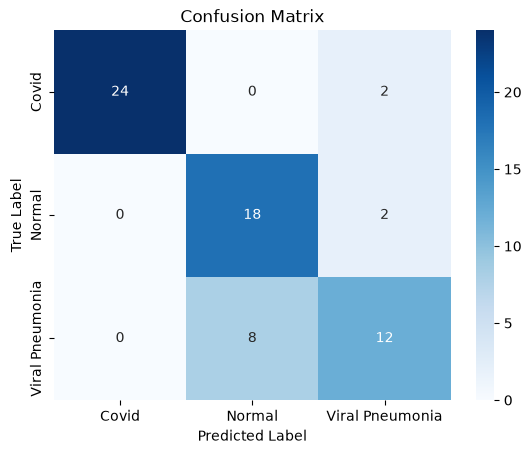

In [ ]:
# Deep CNN Architecture: Building a "bigger engine" from scratch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_2 = Sequential([
    # Block 1: The Basic "Eyes" (Finds edges and contrast)
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    
    # Block 2: The Intermediate "Eyes" (Combines edges into shapes/textures)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Block 3: The Advanced "Eyes" (Finds complex medical patterns)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # The Decision Maker
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# We allow up to 30 epochs because a deeper model built from scratch takes longer to learn.
# EarlyStopping will still automatically stop it if it finishes learning early.
history_2 = model_2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val), 
    epochs=30, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_2, history_2, X_test, y_test)

### Model 3: Transfer Learning VGG16 with GAP, Dropout, and Reduced Learning Rate

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.3600 - loss: 4.5641 - val_accuracy: 0.4510 - val_loss: 4.3045
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.5850 - loss: 4.2349 - val_accuracy: 0.5882 - val_loss: 3.9678
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.7250 - loss: 3.9306 - val_accuracy: 0.9020 - val_loss: 3.7100
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.7450 - loss: 3.7975 - val_accuracy: 0.8235 - val_loss: 3.7993
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.7750 - loss: 3.6817 - val_accuracy: 0.9020 - val_loss: 3.4322
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.9000 - loss: 3.4275 - val_accuracy: 0.8431 - val_loss: 3.5932
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.8500 - loss: 3.3968 - val_accuracy: 0.9412 - val_loss: 3.2256
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.8500 - loss: 3.3038 - val_accuracy: 0.9608 - val_loss: 3.1016
Epoch 9/

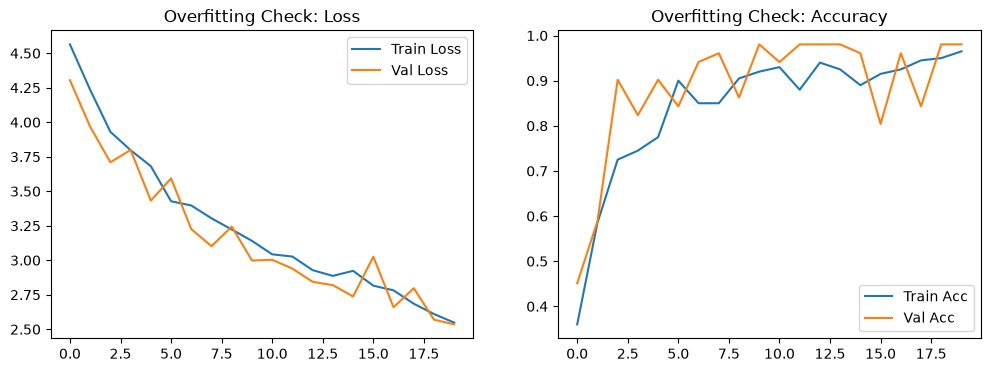

2/3 ━━━━━━━━━━━━━━━━━━━━ 3s 4s/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021DE450DF80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
ROC-AUC Score (OVR): 0.9971

Classification Report:
                  precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       0.94      0.8

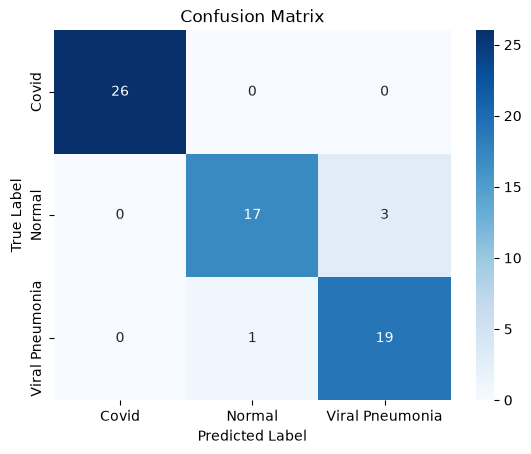

In [10]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Unfreeze the last 4 layers again so it can actually learn X-ray textures
for layer in base_model_vgg.layers[:-4]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_vgg.output)

# Added L2 Regularizer to strictly penalize memorization
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)

x = Dropout(0.5)(x) 
output = Dense(3, activation='softmax')(x)

model_3 = Model(inputs=base_model_vgg.input, outputs=output)

model_3.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_3 = model_3.fit(
    datagen.flow(X_train, y_train, batch_size=32), 
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_3, history_3, X_test, y_test)

### Model 4: Transfer Learning + Data Augmentation with ResNet50 Fine-Tuned

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3750 - loss: 1.2738 - val_accuracy: 0.6275 - val_loss: 1.0779
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3750 - loss: 1.2143 - val_accuracy: 0.2745 - val_loss: 1.1031
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3550 - loss: 1.2528 - val_accuracy: 0.2745 - val_loss: 1.0827
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3600 - loss: 1.2128 - val_accuracy: 0.7451 - val_loss: 1.0567
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3150 - loss: 1.2432 - val_accuracy: 0.2745 - val_loss: 1.0707
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2750 - loss: 1.2625 - val_accuracy: 0.2745 - val_loss: 1.0593
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3500 - loss: 1.1655 - val_accuracy: 0.6667 - val_loss: 1.0188
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4450 - loss: 1.1750 - val_accuracy: 0.6471 - val_loss: 1.0126
Epoch 9/

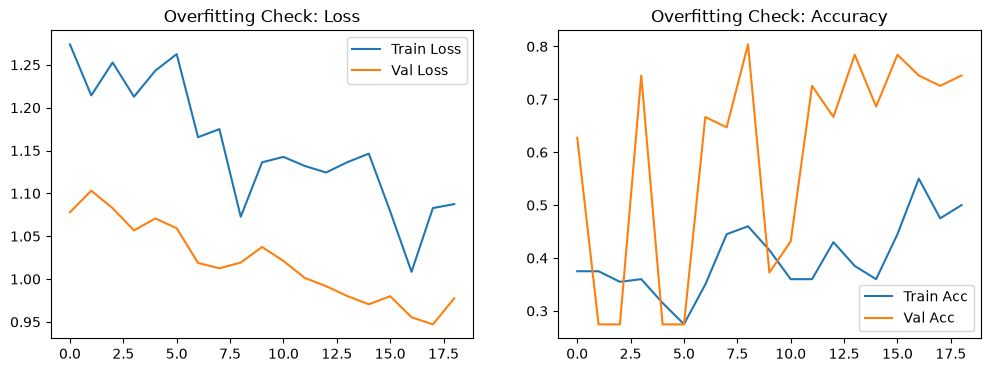

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
ROC-AUC Score (OVR): 0.8909

Classification Report:
                  precision    recall  f1-score   support

          Covid       0.96      0.88      0.92        26
         Normal       0.51      1.00      0.68        20
Viral Pneumonia       1.00      0.15      0.26        20

       accuracy                           0.70        66
      macro avg       0.82      0.68      0.62        66
   weighted avg       0.84      0.70      0.65        66



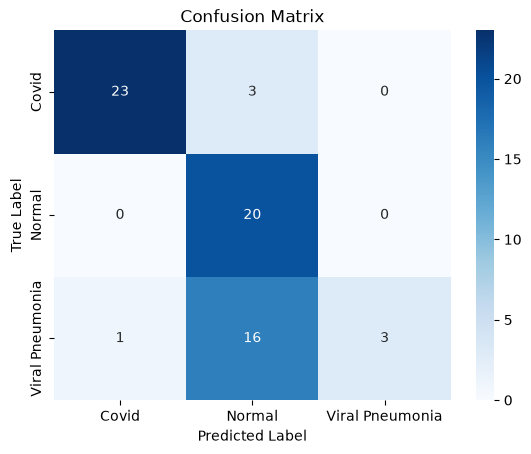

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model_resnet.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_resnet.output)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x) 
output = Dense(3, activation='softmax')(x)

model_4 = Model(inputs=base_model_resnet.input, outputs=output)

model_4.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history_4 = model_4.fit(
    datagen.flow(X_train, y_train, batch_size=32), 
    validation_data=(X_val, y_val), 
    epochs=20, 
    callbacks=[early_stop], 
    class_weight=class_weights_dict
)

evaluate_model(model_4, history_4, X_test, y_test)

### Model Comparison Table

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

def get_model_stats(model, history, X_test, y_test):
    train_acc = history.history['accuracy'][-1]
    
    loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    val_acc = history.history['val_accuracy'][-1]
    if train_acc - test_acc > 0.05: 
        overfitting = "Y"
    else:
        overfitting = "N"
        
    return round(train_acc, 4), round(test_acc, 4), round(f1, 4), overfitting

m1_train, m1_test, m1_f1, m1_over = get_model_stats(model_1, history_1, X_test, y_test)
m2_train, m2_test, m2_f1, m2_over = get_model_stats(model_2, history_2, X_test, y_test)
m3_train, m3_test, m3_f1, m3_over = get_model_stats(model_3, history_3, X_test, y_test)
m4_train, m4_test, m4_f1, m4_over = get_model_stats(model_4, history_4, X_test, y_test)

data = {
    "Model": ["CNN Basic", "Deep CNN", "VGG16", "ResNet50"],
    "Train Acc": [m1_train, m2_train, m3_train, m4_train],
    "Test Acc": [m1_test, m2_test, m3_test, m4_test],
    "F1 Score": [m1_f1, m2_f1, m3_f1, m4_f1],
    "Overfitting (Y/N)": [m1_over, m2_over, m3_over, m4_over]
}

comparison_table = pd.DataFrame(data)


best_idx = comparison_table['Test Acc'].idxmax()

separator = pd.DataFrame([{
    "Model": "-------------------", 
    "Train Acc": "---", 
    "Test Acc": "---", 
    "F1 Score": "---", 
    "Overfitting (Y/N)": "---"
}])

best_row = pd.DataFrame([{
    "Model": f"🏆 BEST: {comparison_table.loc[best_idx, 'Model']}", 
    "Train Acc": comparison_table.loc[best_idx, 'Train Acc'], 
    "Test Acc": comparison_table.loc[best_idx, 'Test Acc'], 
    "F1 Score": comparison_table.loc[best_idx, 'F1 Score'], 
    "Overfitting (Y/N)": comparison_table.loc[best_idx, 'Overfitting (Y/N)']
}])

final_table = pd.concat([comparison_table, separator, best_row], ignore_index=True)

display(final_table)

,Model,Train Acc,Test Acc,F1 Score,Overfitting (Y/N)
0,CNN Basic,0.64,0.7424,0.7515,N
1,Deep CNN,0.825,0.8182,0.8174,N
2,VGG16,0.965,0.9394,0.9392,N
3,ResNet50,0.5,0.697,0.6469,N
4,-------------------,---,---,---,---
5,🏆 BEST: VGG16,0.965,0.9394,0.9392,N


In [13]:
model_3.save("model_VGG.h5")